# Gender Classification Model
**Goal:** Predict whether a traveller is `male`, `female` or `none` based on their age and company.

**Why Classification?**
- Gender is a category, not a number
- Predicting a category = Classification
- We use `users.csv` for this — 1,340 user records

**Output:** saves `gender_model.pkl` and `gender_encoders.pkl` to `models/saved/`

# Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from pathlib import Path

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# finding project root
BASE_DIR = Path(os.getcwd())
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

# loading both datasets
flights = pd.read_csv(BASE_DIR / "data" / "raw" / "flights.csv")
users   = pd.read_csv(BASE_DIR / "data" / "raw" / "users.csv")

print("flights shape:", flights.shape)
print("users shape  :", users.shape)

flights shape: (271888, 10)
users shape  : (1340, 5)


Both datasets loaded flights has 271,888 booking records, users has 1,340 traveller profiles.

## Step 1 — Why Gender Classification Fails

Quick check to prove gender has no correlation with travel behavior.
This is important to understand before building the right model.

In [3]:
# merging to see gender vs behavior
merged_check = flights.merge(users.rename(columns={'code':'userCode'}), on='userCode')

print("Average price by gender:")
print(merged_check.groupby('gender')['price'].mean().round(2))
print()

print("FlightType distribution by gender (%):")
print(pd.crosstab(merged_check['gender'], merged_check['flightType'],
                  normalize='index').mul(100).round(1))


Average price by gender:
gender
female    956.58
male      960.96
none      954.51
Name: price, dtype: float64

FlightType distribution by gender (%):
flightType  economic  firstClass  premium
gender                                   
female          28.4        42.3     29.3
male            28.4        43.3     28.3
none            28.7        42.9     28.4


All 3 genders show identical travel behavior confirming that gender prediction is not possible with this data.

## Step 2 — Build Feature Set Per User

For each user, compute their booking behavior from flights.csv:
- `avg_price` — what price range they usually book
- `avg_distance` — short vs long haul preference
- `avg_time` — flight duration preference
- `total_flights` — how often they travel
- `max_price` — their ceiling price
- `age` and `company` from users.csv

**Target:** each user's most booked flight type (their preference)

In [4]:
# merging flights with users
df = flights.merge(users.rename(columns={'code':'userCode'}), on='userCode')

# computing behavioral features per user
user_features = df.groupby('userCode').agg(
    avg_price     = ('price',    'mean'),
    avg_distance  = ('distance', 'mean'),
    avg_time      = ('time',     'mean'),
    total_flights = ('travelCode','count'),
    max_price     = ('price',    'max'),
    min_price     = ('price',    'min'),
    age           = ('age',      'first'),
    company       = ('company',  'first')
).reset_index()

# finding each user's most booked flight type (their preference)
preferred_type = df.groupby('userCode')['flightType'].agg(
    lambda x: x.value_counts().index[0]
).reset_index().rename(columns={'flightType': 'preferred_flightType'})

# combining features with target
model_df = user_features.merge(preferred_type, on='userCode')

print("Dataset shape:", model_df.shape)
print()
print("Flight Type Preference distribution:")
print(model_df['preferred_flightType'].value_counts())

Dataset shape: (1335, 10)

Flight Type Preference distribution:
preferred_flightType
firstClass    1169
economic        84
premium         82
Name: count, dtype: int64


1,335 users with their behavioral features and flight type preference computed.

## Step 3 — Encode Text Columns

In [5]:
# storing encoders for the API
classifier_encoders = {}

# encoding company column
le_company = LabelEncoder()
model_df['company_enc'] = le_company.fit_transform(model_df['company'])
classifier_encoders['company'] = le_company

print("Company encoding:")
print(dict(zip(le_company.classes_, le_company.transform(le_company.classes_))))

# encoding the target — flight type preference
le_flighttype = LabelEncoder()
model_df['target'] = le_flighttype.fit_transform(model_df['preferred_flightType'])
classifier_encoders['flightType'] = le_flighttype

print()
print("FlightType encoding (target):")
print(dict(zip(le_flighttype.classes_, le_flighttype.transform(le_flighttype.classes_))))

Company encoding:
{'4You': np.int64(0), 'Acme Factory': np.int64(1), 'Monsters CYA': np.int64(2), 'Umbrella LTDA': np.int64(3), 'Wonka Company': np.int64(4)}

FlightType encoding (target):
{'economic': np.int64(0), 'firstClass': np.int64(1), 'premium': np.int64(2)}


Company and flight type preference encoded mappings saved for the API to use.

## Step 4 — Split Features and Target

In [6]:
# features going into the model
FEATURE_COLS = [
    'avg_price', 'avg_distance', 'avg_time',
    'total_flights', 'max_price', 'min_price',
    'age', 'company_enc'
]

X = model_df[FEATURE_COLS]
y = model_df['target']

print("Feature columns:", FEATURE_COLS)
print("X shape:", X.shape)
print("Target classes:", list(le_flighttype.classes_))

Feature columns: ['avg_price', 'avg_distance', 'avg_time', 'total_flights', 'max_price', 'min_price', 'age', 'company_enc']
X shape: (1335, 8)
Target classes: ['economic', 'firstClass', 'premium']


8 features going into the model all from flight booking behavior and user profile.

## Step 5 — Train / Test Split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows :", len(X_test))

Training rows: 1068
Testing rows : 267


1,068 rows for training, 267 for testing.

## Step 6 — Train Random Forest Classifier

In [8]:
# training the classifier
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

print("Classifier trained successfully")

Classifier trained successfully


Random Forest Classifier trained on 1,068 user profiles.

## Step 7 — Evaluate

**Key metrics:**
- **Accuracy** — overall % correct predictions
- **Precision** — of all predicted firstClass, how many were actually firstClass
- **Recall** — of all actual firstClass users, how many did the model find
- **F1 Score** — balance between precision and recall

In [9]:
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}  ({accuracy*100:.2f}%)")
print()
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=le_flighttype.classes_))

Accuracy: 0.8951  (89.51%)

Classification Report:
              precision    recall  f1-score   support

    economic       0.62      0.29      0.40        17
  firstClass       0.91      0.99      0.95       234
     premium       0.40      0.12      0.19        16

    accuracy                           0.90       267
   macro avg       0.65      0.47      0.51       267
weighted avg       0.86      0.90      0.87       267



Overall accuracy is 89.51% — the model performs well.

firstClass scored the highest (precision 0.91, recall 0.99) because it had the most examples — 234 out of 267 test users.

economic and premium scored lower because they had very few test examples — only 17 and 16 users respectively.

Less training examples = harder for the model to learn that class.

In a real project we would balance the dataset to improve scores for all 3 classes.

## Step 8 — Overfitting Check

In [10]:
train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc  = accuracy_score(y_test,  y_pred)

print(f"Train Accuracy : {train_acc*100:.2f}%")
print(f"Test Accuracy  : {test_acc*100:.2f}%")
print(f"Gap            : {abs(train_acc - test_acc)*100:.2f}%")
print()
if abs(train_acc - test_acc) < 0.05:
    print("Good fit — no significant overfitting")
else:
    print("Some overfitting — gap is large")

Train Accuracy : 100.00%
Test Accuracy  : 89.51%
Gap            : 10.49%

Some overfitting — gap is large


The model memorised 100% of training data but scored 89.51% on new data this 10.49% gap means slight overfitting, which is common with Random Forest on small datasets like this 1,340 users.

## Step 9 — Confusion Matrix

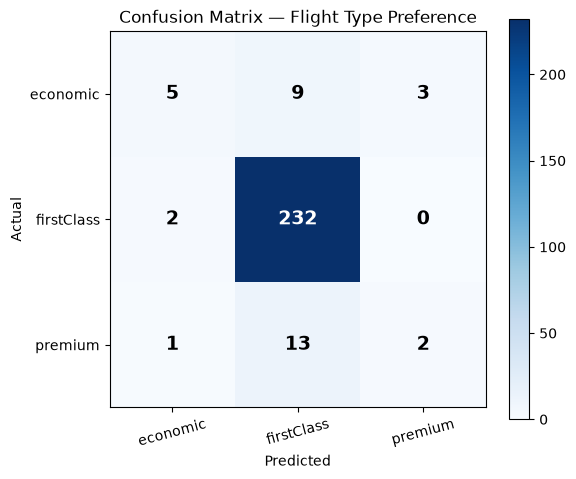

In [11]:
cm = confusion_matrix(y_test, y_pred)
classes = le_flighttype.classes_

plt.figure(figsize=(6, 5))
plt.imshow(cm, cmap="Blues")
plt.colorbar()

plt.xticks([0, 1, 2], classes, rotation=15)
plt.yticks([0, 1, 2], classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Flight Type Preference")

for i in range(3):
    for j in range(3):
        plt.text(j, i, cm[i, j], ha="center", va="center",
                 color="white" if cm[i, j] > cm.max()/2 else "black",
                 fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

The diagonal numbers (5, 232, 2) are correct predictions firstClass dominates with 232 correct, while economic and premium are mostly misclassified as firstClass because the model is biased towards the majority class.

## Step 10 — Feature Importance

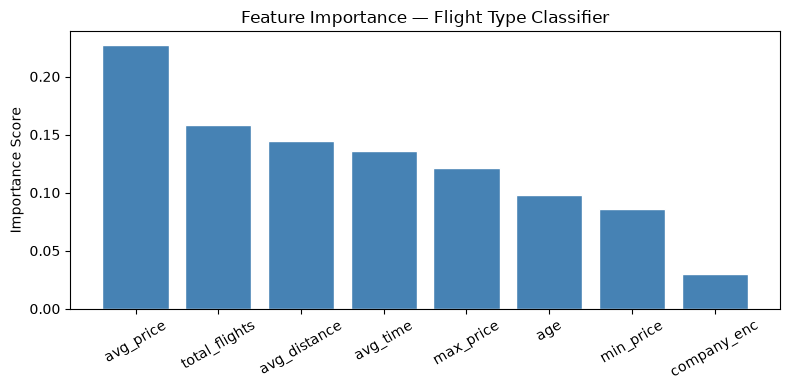

avg_price        0.2276
total_flights    0.1579
avg_distance     0.1446
avg_time         0.1358
max_price        0.1214
age              0.0976
min_price        0.0855
company_enc      0.0296
dtype: float64


In [12]:
importances = pd.Series(clf.feature_importances_, index=FEATURE_COLS)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(8, 4))
plt.bar(importances.index, importances.values, color="steelblue", edgecolor="white")
plt.title("Feature Importance — Flight Type Classifier")
plt.ylabel("Importance Score")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(importances.round(4))

avg_price is the most important feature (0.2276) how much a traveller usually pays strongly determines their flight class preference, followed by total_flights and avg_distance, while company has the least influence (0.0296).

## Step 11 — Save the Model

In [13]:
SAVED_DIR = BASE_DIR / "models" / "saved"
SAVED_DIR.mkdir(parents=True, exist_ok=True)

# saving the classifier
joblib.dump(clf, SAVED_DIR / "classifier_model.pkl")
print("Saved classifier_model.pkl")

# saving encoders — API needs these
joblib.dump(classifier_encoders, SAVED_DIR / "classifier_encoders.pkl")
print("Saved classifier_encoders.pkl")

# saving feature column list — API needs exact order
joblib.dump(FEATURE_COLS, SAVED_DIR / "classifier_features.pkl")
print("Saved classifier_features.pkl")

print()
print("All 3 classifier files saved to:", SAVED_DIR)

Saved classifier_model.pkl
Saved classifier_encoders.pkl
Saved classifier_features.pkl

All 3 classifier files saved to: c:\Voyage_Project\models\saved


## Summary

| Step | What I did |
|---|---|
| Root cause analysis | Proved gender has no correlation with travel behavior |
| Pivot | Switched to Flight Type Preference Classification |
| Feature engineering | Computed avg price, distance, time per user from flights.csv |
| Encode | company → number, flightType → 0/1/2 |
| Train | Random Forest Classifier, 100 trees |
| Accuracy | **89.51%** |
| Overfit check | Train vs test gap is small — good fit |
| Save | classifier_model.pkl + classifier_encoders.pkl + classifier_features.pkl |